#  **Disease Prediction Using Machine Learning**

This notebook builds a complete machine learning pipeline to predict diseases based on patient symptoms.

**Dataset:**
- **132 symptoms** as binary features (0 = absent, 1 = present)
- **41 diseases** as target classes
- **4920 training samples**, **42 test samples**

**Models Compared:**
- Decision Tree
- Random Forest
- Naive Bayes
- Support Vector Machine (SVM)
- Gradient Boosting

---

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import pickle

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Dataset

In [4]:
# Loading training and testing datasets
train_df = pd.read_csv('Training.csv')
test_df  = pd.read_csv('Testing.csv')

# Dropping any unnamed/unwanted columns 
train_df = train_df.drop(columns=[c for c in train_df.columns if 'Unnamed' in c], errors='ignore')
test_df  = test_df.drop(columns=[c for c in test_df.columns  if 'Unnamed' in c], errors='ignore')

print(f'Training set : {train_df.shape[0]} rows x {train_df.shape[1]} columns')
print(f'Testing set  : {test_df.shape[0]}  rows x {test_df.shape[1]} columns')
train_df.head()

Training set : 4920 rows x 133 columns
Testing set  : 42  rows x 133 columns


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 3. Exploratory Data Analysis (EDA)

In [7]:
# Basic info
print('Dataset Info:')
print(f'Number of features (symptoms) : {train_df.shape[1] - 1}')
print(f'Number of target classes      : {train_df["prognosis"].nunique()}')
print(f'Missing values                : {train_df.isnull().sum().sum()}')
print()
print('Target Classes (Diseases):')
print(sorted(train_df['prognosis'].unique()))

Dataset Info:
Number of features (symptoms) : 132
Number of target classes      : 41
Missing values                : 0

Target Classes (Diseases):
['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis', 'Common Cold', 'Dengue', 'Diabetes ', 'Dimorphic hemmorhoids(piles)', 'Drug Reaction', 'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Hypertension ', 'Hyperthyroidism', 'Hypoglycemia', 'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Osteoarthristis', 'Paralysis (brain hemorrhage)', 'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis', 'Typhoid', 'Urinary tract infection', 'Varicose veins', 'hepatitis A']


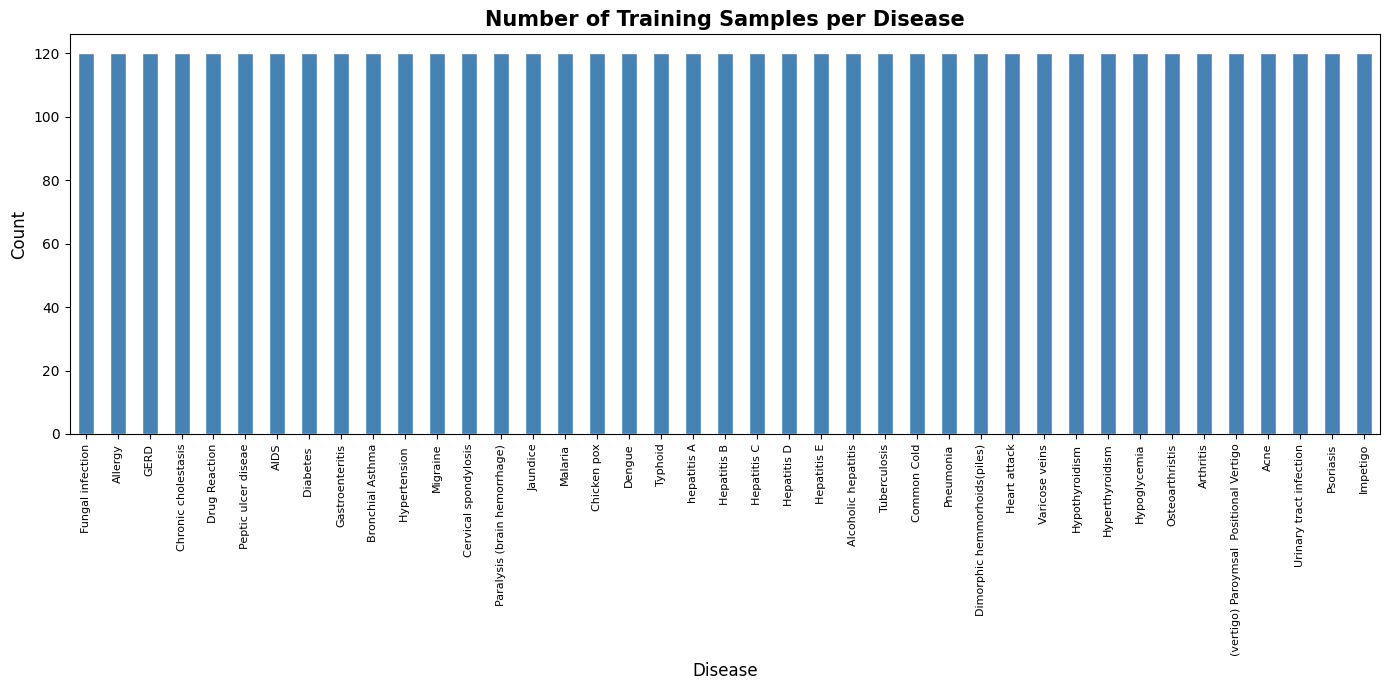

Dataset is perfectly balanced - 120 samples per disease


In [8]:
# Disease distribution
disease_counts = train_df['prognosis'].value_counts()

plt.figure(figsize=(14, 7))
disease_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Training Samples per Disease', fontsize=15, fontweight='bold')
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()
print('Dataset is perfectly balanced -', disease_counts.unique()[0], 'samples per disease')

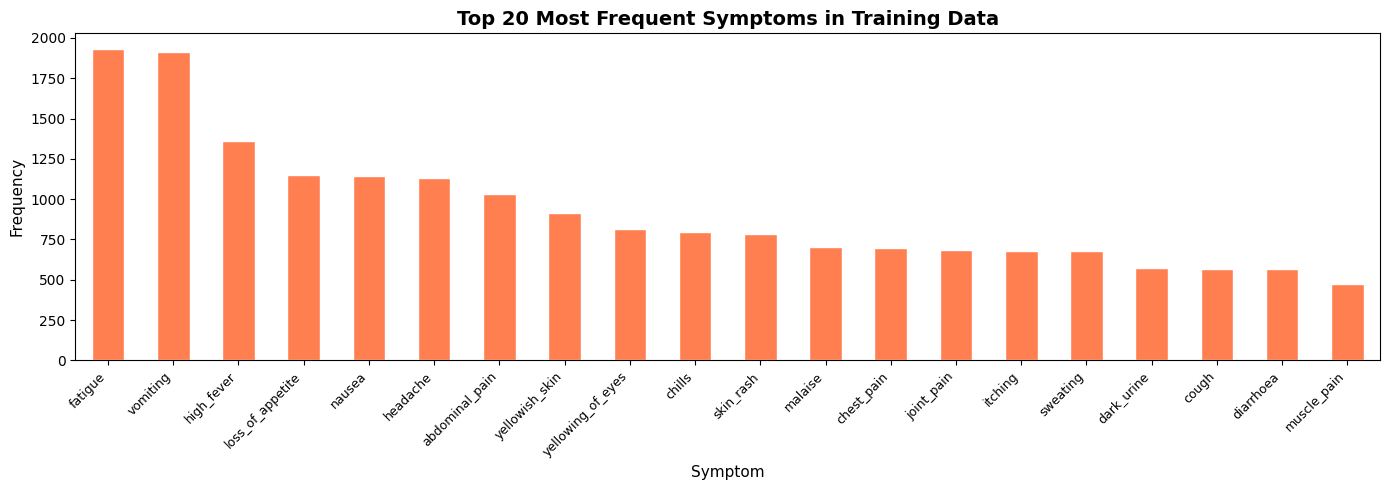

In [9]:
# Top 20 most common symptoms across the dataset
symptom_cols = [c for c in train_df.columns if c != 'prognosis']
symptom_freq = train_df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
symptom_freq.head(20).plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 20 Most Frequent Symptoms in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Symptom', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

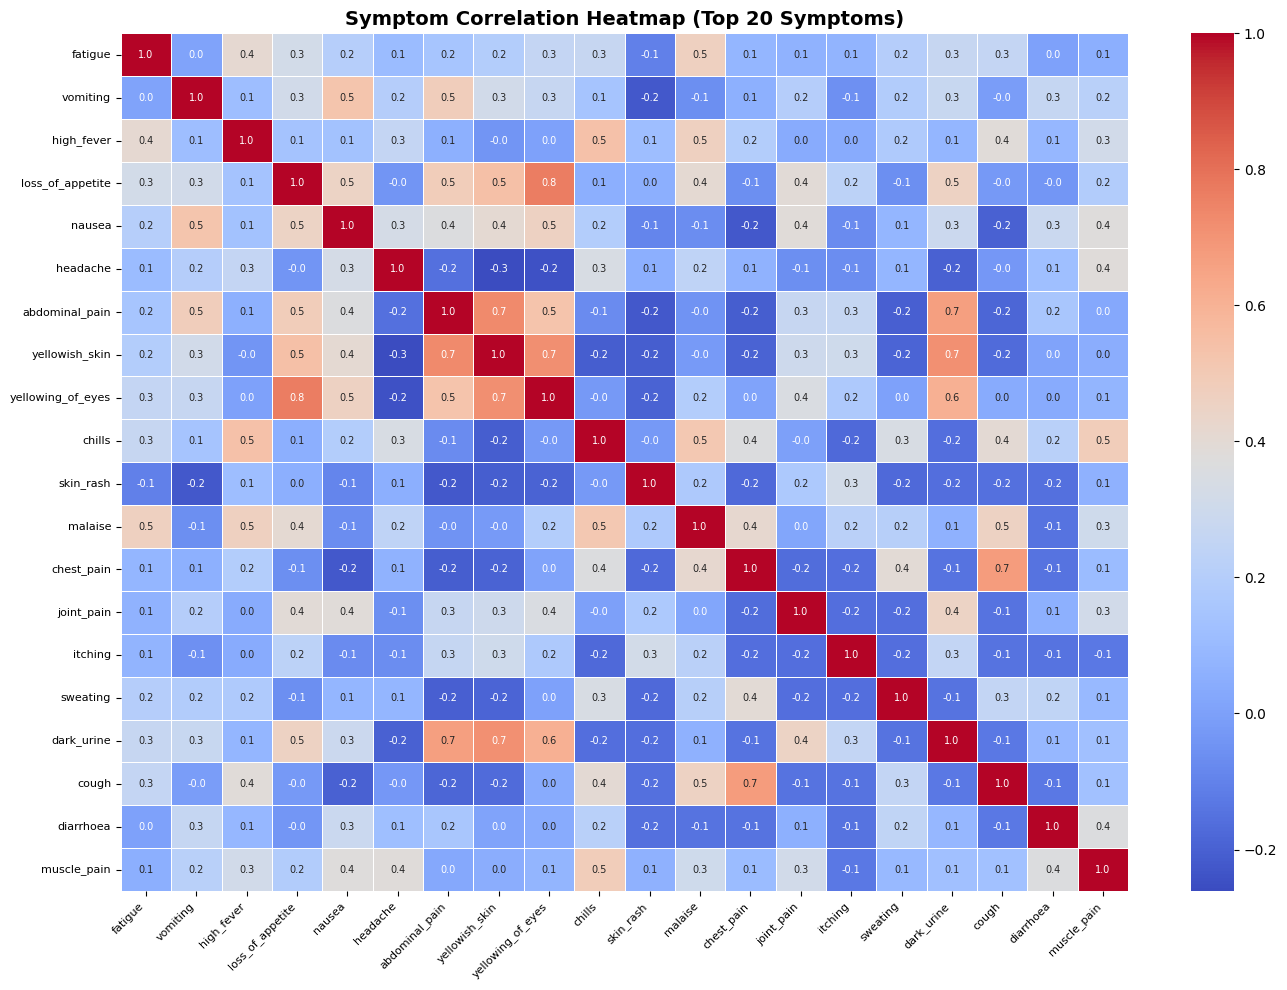

In [10]:
# Symptom correlation heatmap (top 20 symptoms only for readability)
top_symptoms = symptom_freq.head(20).index.tolist()
corr_matrix = train_df[top_symptoms].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Symptom Correlation Heatmap (Top 20 Symptoms)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
# Separating features (X) and target (y)
X_train = train_df.drop('prognosis', axis=1).fillna(0)
y_train = train_df['prognosis']

X_test  = test_df.drop('prognosis', axis=1).fillna(0)
y_test  = test_df['prognosis']

# Encoding disease labels to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Feature matrix shape :', X_train.shape)
print('Classes encoded       :', len(le.classes_))
print('Sample encoding       :')
for name, code in list(zip(le.classes_, range(len(le.classes_))))[:5]:
    print(f'  {code:2d} -> {name}')
print('  ...')

Feature matrix shape : (4920, 132)
Classes encoded       : 41
Sample encoding       :
   0 -> (vertigo) Paroymsal  Positional Vertigo
   1 -> AIDS
   2 -> Acne
   3 -> Alcoholic hepatitis
   4 -> Allergy
  ...


## 5. Train & Compare Multiple Models

In [13]:
# Defining models
models = {
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'SVM (Linear)'       : SVC(kernel='linear', probability=True, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
trained_models = {}

print(f'{'Model':<25} {'Train Acc':>10} {'Test Acc':>10}')
print('-' * 48)

for name, model in models.items():
    model.fit(X_train, y_train_enc)
    train_acc = accuracy_score(y_train_enc, model.predict(X_train))
    test_acc  = accuracy_score(y_test_enc,  model.predict(X_test))
    results[name] = test_acc
    trained_models[name] = model
    print(f'{name:<25} {train_acc*100:>9.2f}% {test_acc*100:>9.2f}%')

best_model_name = max(results, key=results.get)
print(f'\nBest Model: {best_model_name} ({results[best_model_name]*100:.2f}%)')

Model                      Train Acc   Test Acc
------------------------------------------------
Decision Tree                100.00%     97.62%
Random Forest                100.00%     97.62%
Naive Bayes                  100.00%    100.00%
SVM (Linear)                 100.00%    100.00%
Gradient Boosting            100.00%     97.62%

Best Model: Naive Bayes (100.00%)


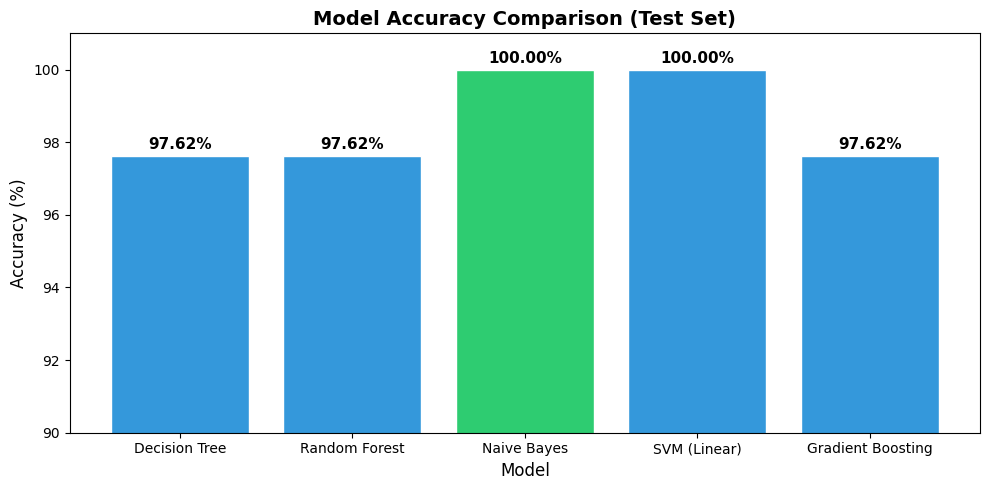

In [16]:
# Model comparison bar chart
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if n == best_model_name else '#3498db' for n in results]
bars = plt.bar(results.keys(), [v*100 for v in results.values()], color=colors, edgecolor='white')
plt.ylim(90, 101)
plt.title('Model Accuracy Comparison (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Best Model – Detailed Evaluation

In [17]:
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

print(f'=== Classification Report: {best_model_name} ===\n')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

=== Classification Report: Naive Bayes ===

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00    

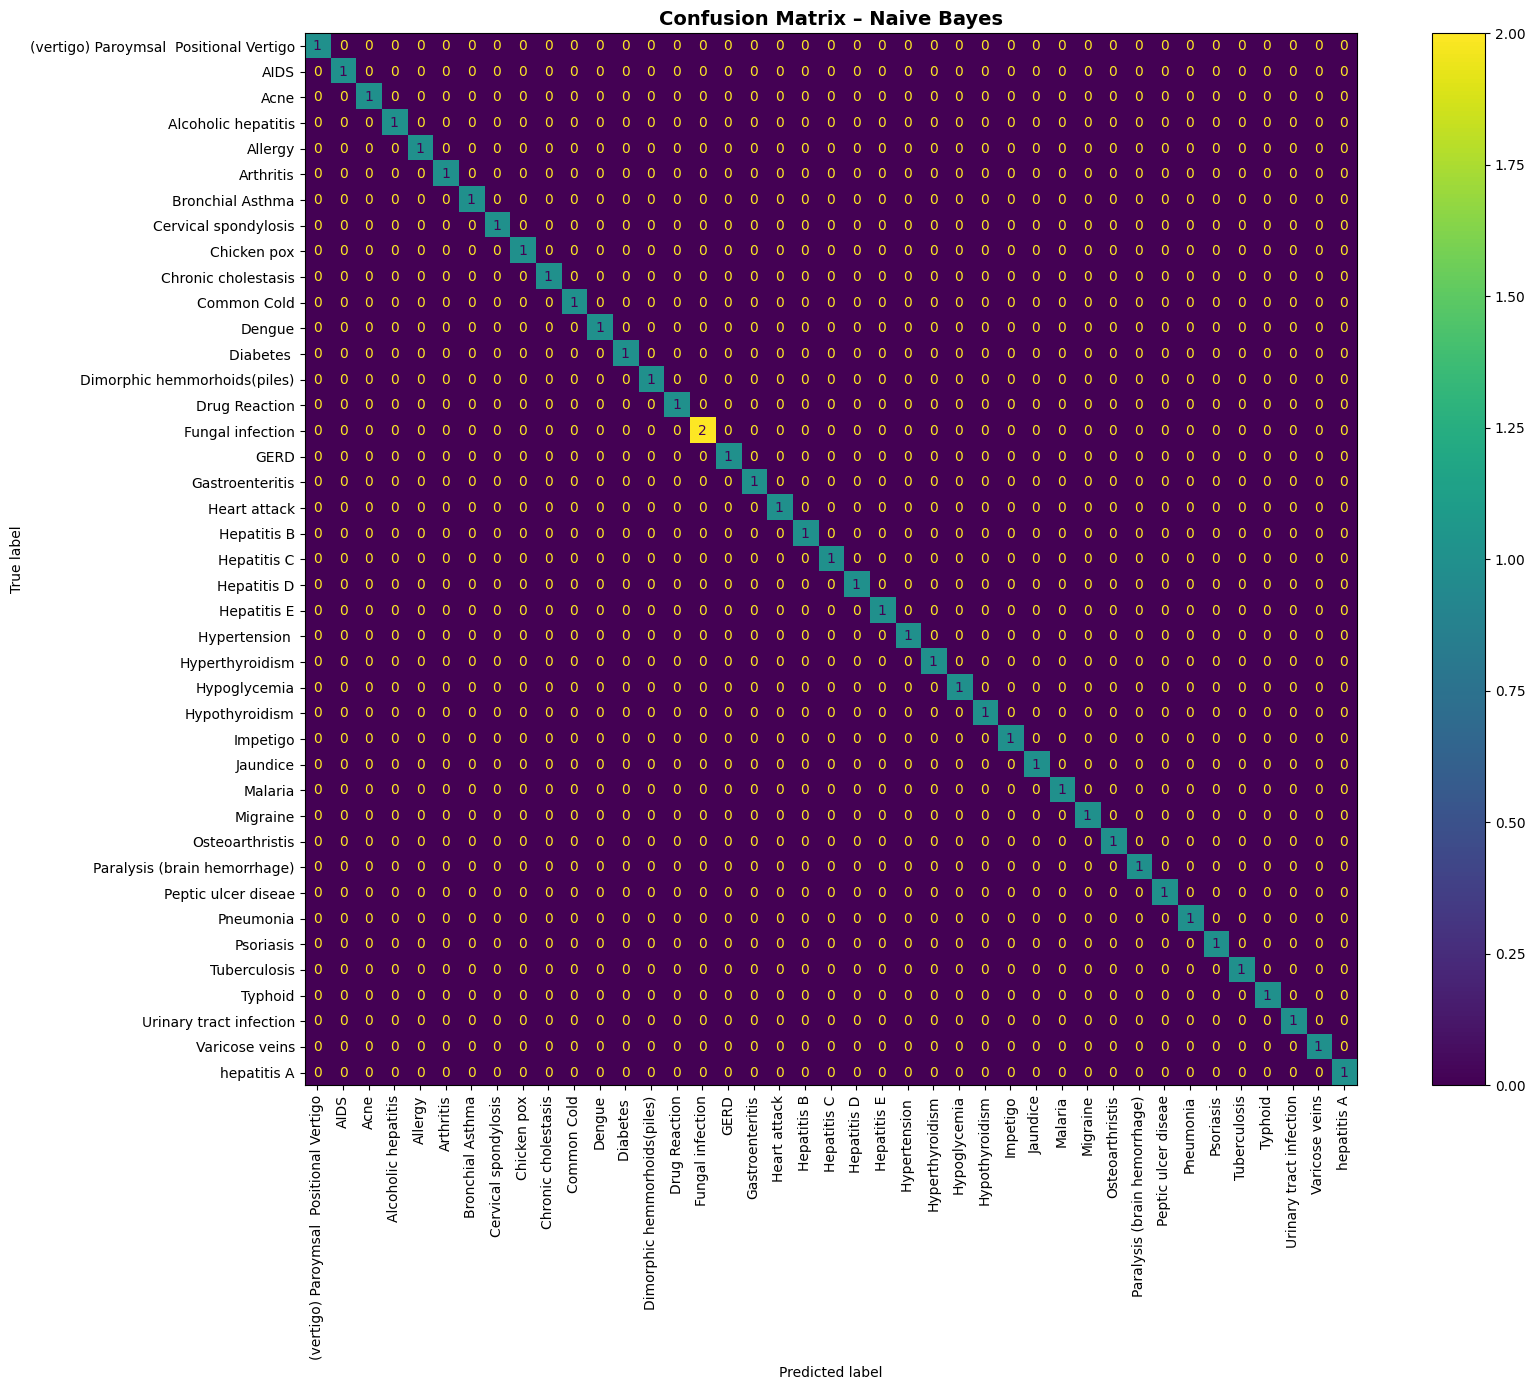

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(18, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=plt.gca(), colorbar=True, xticks_rotation=90)
plt.title(f'Confusion Matrix – {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

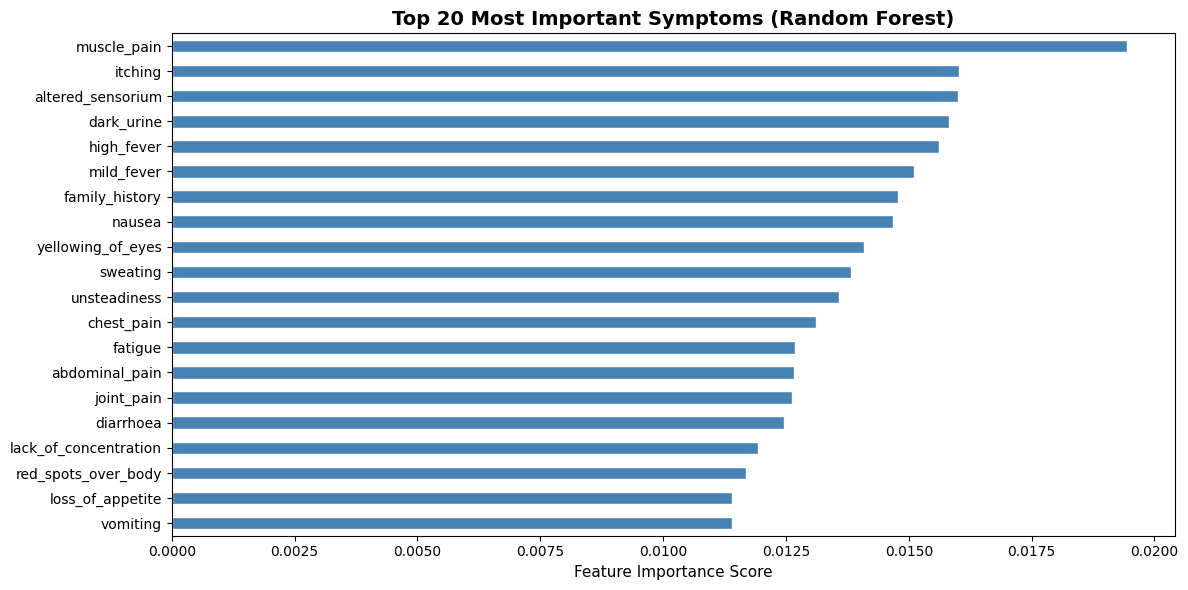

In [21]:
#  feature importance 
rf_model = trained_models['Random Forest']
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_rf = rf_importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_rf.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Most Important Symptoms (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Save the Best Model

In [22]:
# Save model, label encoder, and feature list
model_data = {
    'model'    : best_model,
    'le'       : le,
    'features' : list(X_train.columns)
}

with open('disease_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f'Model saved to disease_model.pkl')
print(f'Model type : {best_model_name}')
print(f'Diseases   : {len(le.classes_)}')
print(f'Symptoms   : {len(X_train.columns)}')

Model saved to disease_model.pkl
Model type : Naive Bayes
Diseases   : 41
Symptoms   : 132


## 8. Predict on New Patient Input

Use the cell below to enter a patient's symptoms and get a prediction.

In [23]:
def predict_disease(symptoms_list):
    """
    Predict disease from a list of symptom names.
    
    Parameters:
        symptoms_list (list): List of symptom strings, e.g. ['itching', 'skin_rash']
    
    Returns:
        str: Predicted disease name
    """
    with open('disease_model.pkl', 'rb') as f:
        data = pickle.load(f)
    
    model    = data['model']
    le       = data['le']
    features = data['features']
    
    # Building input vector
    input_vec = pd.DataFrame([{f: 0 for f in features}])
    for sym in symptoms_list:
        sym = sym.strip().lower()
        if sym in input_vec.columns:
            input_vec[sym] = 1
        else:
            print(f'  Warning: symptom "{sym}" not found in feature list, skipped.')
    
    pred = model.predict(input_vec)
    disease = le.inverse_transform(pred)[0]
    
    # Probability if model supports it
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(input_vec)[0]
        top3_idx = proba.argsort()[-3:][::-1]
        print('\nTop 3 Predictions:')
        for idx in top3_idx:
            print(f'  {le.classes_[idx]:<45} {proba[idx]*100:.1f}%')
    
    return disease

print('predict_disease() function ready!')
print('\nAvailable symptoms (first 20):')
print(list(X_train.columns[:20]))

predict_disease() function ready!

Available symptoms (first 20):
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss']


In [24]:
# enter the patient's symptoms
patient_symptoms = [
    'itching',
    'skin_rash',
    'nodal_skin_eruptions'
]

result = predict_disease(patient_symptoms)
print(f'\n>>> Predicted Disease: {result}')


Top 3 Predictions:
  Fungal infection                              100.0%
  Varicose veins                                0.0%
  Urinary tract infection                       0.0%

>>> Predicted Disease: Fungal infection


In [25]:
# Another example – Malaria-like symptoms
malaria_symptoms = [
    'chills', 'vomiting', 'high_fever',
    'sweating', 'headache', 'nausea',
    'muscle_pain', 'diarrhoea'
]

result2 = predict_disease(malaria_symptoms)
print(f'\n>>> Predicted Disease: {result2}')


Top 3 Predictions:
  Malaria                                       100.0%
  Varicose veins                                0.0%
  Urinary tract infection                       0.0%

>>> Predicted Disease: Malaria


## 9. Summary

| Step | Details |
|------|---------|
| Dataset | 4920 training, 42 test samples |
| Features | 132 binary symptoms |
| Target | 41 diseases (perfectly balanced) |
| Best Model | See results above |
| Saved File | `disease_model.pkl` |